# Computer Infrastructure - Problems Portfolio 

This notebook contains a collection of problems completed for the Computer Infrastructure course at ATU.  
Each section includes the problem statement, reasoning, and the corresponding solution with code examples.  

## Problem 1: Downloading Hourly FAANG Stock Data Using yfinance

### Description  
This problem requires writing a Python function named `get_data()` that uses the yfinance package to download **hourly stock data** for the **five FAANG companies** — Facebook (META), Apple (AAPL), Amazon (AMZN), Netflix (NFLX), and Google (GOOG) — covering the **previous five days**.

The function must:

- Save the retrieved dataset as a CSV file in the data folder.
- Use a filename in the format **`YYYYMMDD-HHmmss.csv`**, where:

  - `YYYYMMDD` represents the current year, month, and day.
  - `HHmmss` represents the hour, minute, and second at the time the file is created.

In [1]:
# Importing all libraries
import yfinance as yf
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt

In [2]:
# Get data function + faangs
def get_data():
    tickers = ['META', 'AAPL', 'AMZN', 'NFLX', 'GOOG']

In [3]:
# Get data function + FAANGs
def get_data():
    tickers = ['META', 'AAPL', 'AMZN', 'NFLX', 'GOOG']  # inside the function
    
    # Get data of the last 5 days for the 5 FAANG stocks
    data = yf.download(
        tickers=tickers,
        period="5d",
        interval="1h",
        group_by="ticker",
        auto_adjust=True
    )

    # Create a timestamped filename
    timestamp = dt.datetime.now().strftime("%Y%m%d-%H%M%S")
    filename = f"data/{timestamp}.csv"

    # Save the dataset as a CSV file in the data folder
    data.to_csv(filename)

    print(f"Data saved to: {filename}")
    return data

df = get_data()

[*********************100%***********************]  5 of 5 completed

Data saved to: data/20251217-094924.csv


## References

1. AlgoTrading101. (n.d.). *A Complete Guide to yfinance*. Retrieved from [https://algotrading101.com/learn/yfinance-guide/?utm_source=chatgpt.com](https://algotrading101.com/learn/yfinance-guide/?utm_source=chatgpt.com)

2. AppDividend. (n.d.). *Creating a filename containing date or time in Python*. Retrieved from [https://appdividend.com/creating-a-filename-containing-date-or-time-in-python/](https://appdividend.com/creating-a-filename-containing-date-or-time-in-python/)

3. Cicek, M. (n.d.). *yfinance — Get Your Own Stock Data*. Kaggle. Retrieved from [https://www.kaggle.com/code/mustafacicek/yfinance-get-your-own-stock-data](https://www.kaggle.com/code/mustafacicek/yfinance-get-your-own-stock-data)

4. GeeksforGeeks. (n.d.). *How to create filename containing date or time in Python*. Retrieved from [https://www.geeksforgeeks.org/python/how-to-create-filename-containing-date-or-time-in-python/](https://www.geeksforgeeks.org/python/how-to-create-filename-containing-date-or-time-in-python/)

5. GeeksforGeeks. (n.d.). *What is yfinance Library*. Retrieved from [https://www.geeksforgeeks.org/machine-learning/what-is-yfinance-library/](https://www.geeksforgeeks.org/machine-learning/what-is-yfinance-library/)

6. Juunge, K. (2020, May 7). *yfinance: 10 Ways to Get Stock Data with Python*. Medium. Retrieved from [https://medium.com/@kasperjuunge/yfinance-10-ways-to-get-stock-data-with-python-6677f49e8282](https://medium.com/@kasperjuunge/yfinance-10-ways-to-get-stock-data-with-python-6677f49e8282)

7. Python Forum. (n.d.). *Creating filenames with date/time*. Retrieved from [https://python-forum.io/thread-28878.html](https://python-forum.io/thread-28878.html)

8. Ranaroussi, M. (n.d.). *yfinance — API Reference: download()*. Retrieved from [https://ranaroussi.github.io/yfinance/reference/api/yfinance.download.html?utm_source=chatgpt.com](https://ranaroussi.github.io/yfinance/reference/api/yfinance.download.html?utm_source=chatgpt.com)

9. Ranaroussi, M. (n.d.). *yfinance — Homepage*. Retrieved from [https://ranaroussi.github.io/yfinance/](https://ranaroussi.github.io/yfinance/)

10. SAFE Community. (n.d.). *Write CSV file where filename includes date/timestamp of translation — currently getting multiple CSVs*. Retrieved from [https://community.safe.com/data-7/write-csv-file-where-filename-includes-date-timestamp-of-translation-currently-getting-multiple-csvs-12292](https://community.safe.com/data-7/write-csv-file-where-filename-includes-date-timestamp-of-translation-currently-getting-multiple-csvs-12292)

11. StackOverflow. (2019, December 13). *Add timestamp to file name during saving DataFrame in CSV*. Retrieved from [https://stackoverflow.com/questions/67505537/add-timestamp-to-file-name-during-saving-data-frame-in-csv](https://stackoverflow.com/questions/67505537/add-timestamp-to-file-name-during-saving-data-frame-in-csv)

## Problem 2: Plotting FAANG Stock Data

### Description
This problem requires writing a Python function named `plot_data()` that reads the **most recent CSV data file** from the **data** folder (created in Problem 1) and generates a line plot showing the **Close prices** of the **five FAANG companies** — Facebook (META), Apple (AAPL), Amazon (AMZN), Netflix (NFLX), and Google (GOOG).

The function must:
- Open the **latest CSV file** in the `data` folder.  
- Plot the **Close prices** for each of the five stocks on a single chart.  
- Include **axis labels**, a **legend**, and a **date-based title**.  
- Save the plot as a **PNG image** in a folder called `plots` in the root directory.  
- Use a filename in the format **`YYYYMMDD-HHmmss.png`**, where:
  - `YYYYMMDD` represents the current year, month, and day.
  - `HHmmss` represents the hour, minute, and second at the time the plot is created.

In [4]:
def load_close_prices(filename):
    # Load CSV file with multi-level headers
    df_raw = pd.read_csv(filename, header=[0,1], index_col=0, parse_dates=True)
    
    # Extract only the columns with 'Close'
    close_df = df_raw.xs('Close', level=1, axis=1)
    
    return close_df

In [5]:
def generate_filename():
    # Generate a timestamp string in the format YYYYMMDD-HHmmss
    timestamp = dt.datetime.now().strftime("%Y%m%d-%H%M%S")
    
    # Create the output filename inside 'plots' folder
    return f"plots/{timestamp}.png"

In [6]:
def plot_data():
    # Specify the latest data file
    latest_file = "data/20251204-165637.csv"
    
    # Load only closing prices from CSV
    close_df = load_close_prices(latest_file)
    
    # Extract last date from index to use it as plot title
    title = close_df.index[-1].strftime("%Y-%m-%d")
    
    # Generate the output filename
    filename = generate_filename()
    
    # Plot all closing prices on the same figure
    ax = close_df.plot(title=f"Close Prices - {title}", xlabel="Date", ylabel="Price")
    
    # Get the figure from the axes object so we can save it
    fig = ax.get_figure()
    
    # Save the figure as a PNG file in the 'plots' folder
    fig.savefig(filename)
    
    # Print confirmation with the saved filename
    print(f"Plot saved to: {filename}")


Plot saved to: plots/20251217-094924.png


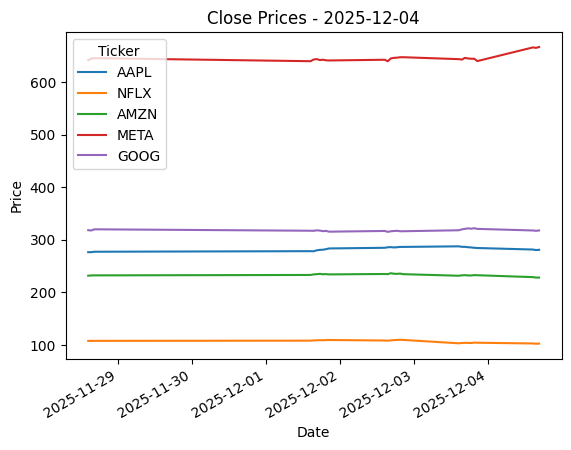

In [7]:
plot_data()

## References

1. Matplotlib. (n.d.). *matplotlib.pyplot.savefig*. Retrieved from [https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html)

2. Pandas. (n.d.). *DataFrame*. Retrieved from [https://pandas.pydata.org/docs/reference/frame.html](https://pandas.pydata.org/docs/reference/frame.html)

3. Pandas. (n.d.). *DatetimeIndex.strftime*. Retrieved from [https://pandas.pydata.org/docs/reference/api/pandas.DatetimeIndex.strftime.html](https://pandas.pydata.org/docs/reference/api/pandas.DatetimeIndex.strftime.html)

4. Pandas. (n.d.). *Series*. Retrieved from [https://pandas.pydata.org/docs/reference/series.html](https://pandas.pydata.org/docs/reference/series.html)

5. Pandas. (n.d.). *Timeseries plotting*. Retrieved from [https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#timeseries-plotting](https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#timeseries-plotting)

6. Pandas. (n.d.). *Visualization — plotting with multiple columns*. Retrieved from [https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html#plotting-with-multiple-columns](https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html#plotting-with-multiple-columns)

7. Pandas. (n.d.). *Working with DataFrames*. Retrieved from [https://www.w3schools.com/python/pandas/pandas_dataframes.asp](https://www.w3schools.com/python/pandas/pandas_dataframes.asp)

8. Stack Overflow. (2019). *How to deal with multi-level column names downloaded with yfinance*. Retrieved from [https://stackoverflow.com/questions/63107594/how-to-deal-with-multi-level-column-names-downloaded-with-yfinance?utm_source=chatgpt.com](https://stackoverflow.com/questions/63107594/how-to-deal-with-multi-level-column-names-downloaded-with-yfinance?utm_source=chatgpt.com)

9. Stack Overflow. (2019). *How to deal with multi-level column names downloaded with yfinance (Answer)*. Retrieved from [https://stackoverflow.com/questions/63107594/how-to-deal-with-multi-level-column-names-downloaded-with-yfinance/63107801#63107801](https://stackoverflow.com/questions/63107594/how-to-deal-with-multi-level-column-names-downloaded-with-yfinance/63107801#63107801)

10. Stack Overflow. (2019). *How to organise multiple stock data in pandas DataFrame for plotting*. Retrieved from [https://stackoverflow.com/questions/72456084/how-to-organise-multiple-stock-data-in-pandas-dataframe-for-plotting](https://stackoverflow.com/questions/72456084/how-to-organise-multiple-stock-data-in-pandas-dataframe-for-plotting)

11. Stack Overflow. (2019). *Pandas df index strftime*. Retrieved from [https://stackoverflow.com/questions/60173111/pandas-df-index-strftimeh](https://stackoverflow.com/questions/60173111/pandas-df-index-strftimeh)

## Problem 3: Creating an Executable Python Script (**faang.py**)

### Description

The goal of this problem is to create a Python script called **`faang.py`** in the root directory of the repository.  
The script must contain the functions developed in the previous exercises and be executable directly from the terminal using the command:

`./faang.py`

When executed, the script should download the FAANG stock data and generate the corresponding plot.


### Execution

To solve this problem, I created a Python script named faang.py in the root of the repository and copied into it the functions previously developed in the notebook.

At the top of the file, I added the following shebang line:

`#!/usr/bin/env python3`

This line tells the operating system to execute the script using the Python 3 interpreter, allowing the file to be run directly from the terminal.

To make the script executable, I changed its permissions by running the following command in the terminal:

`chmod u+x faang.py`

This command grants execution permissions to the file owner, making it possible to run the script with **./faang.py.**

## References

1. Stack Overflow. (n.d.). *How do I execute a bash script in terminal?* Retrieved from https://stackoverflow.com/questions/2177932/how-do-i-execute-a-bash-script-in-terminal

2. Ask Different (Apple Stack Exchange). (n.d.). *How do I run a .sh or command file in Terminal?* Retrieved from https://apple.stackexchange.com/questions/235128/how-do-i-run-a-sh-or-command-file-in-terminal

3. Stack Overflow. (n.d.). *How can I run a shell script on a Unix console or Mac terminal?* Retrieved from https://stackoverflow.com/questions/733824/how-can-i-run-a-shell-script-on-a-unix-console-or-mac-terminal

4. Stack Overflow. (n.d.). *Purpose of /usr/bin/python3 shebang*. Retrieved from https://stackoverflow.com/questions/7670303/purpose-of-usr-bin-python3-shebang

5. University of Pennsylvania, CETS. (n.d.). *Understanding chmod.* Retrieved from https://cets.seas.upenn.edu/answers/chmod.html

6. LinuxConfig. (n.d.). *Understanding chmod: the difference between u+x and +x.* Retrieved from https://linuxconfig.org/understanding-chmod-the-difference-between-ux-and-x

7. Ask Ubuntu. (n.d.). *chmod u+x versus chmod +x.* Retrieved from https://askubuntu.com/questions/29589/chmod-ux-versus-chmod-x

## Problem 4: Automation

### Description

The aim of this problem is to automate the execution of the Python script `faang.py` using GitHub Actions.  
Instead of running the script manually, a scheduled workflow is created so that the data collection and analysis process runs automatically every Saturday morning.

The workflow is defined in a file named `faang.yml`, stored in the `.github/workflows/` directory at the root of the repository.  
This setup ensures that the script is executed in a clean and consistent environment and demonstrates the use of automation for recurring tasks.

---

### Workflow Execution

GitHub Actions is used to schedule and execute the script.  
The workflow is triggered by a cron-based schedule and runs the `faang.py` script without requiring any user interaction.

The workflow file is located at:

`.github/workflows/faang.yml`




The complete workflow configuration is shown below.

---

```yaml
name: Run FAANG Script Weekly

on:
  schedule:
    - cron: '0 7 * * 6'

jobs:
  run-script:
    runs-on: ubuntu-latest

    steps:
    - name: Checkout repository
      uses: actions/checkout@v3

    - name: Set up Python
      uses: actions/setup-python@v4
      with:
        python-version: '3.x'

    - name: Install dependencies
      run: |
        python -m pip install --upgrade pip
        pip install yfinance pandas matplotlib

    - name: Run FAANG script
      run: python faang.py


--- 

### Step-by-step explanation of the workflow

#### *Workflow name*
The name field assigns a clear label to the workflow, making it easy to identify within the GitHub Actions interface.

#### *Trigger configuration*
The schedule event sets the workflow to run automatically based on a cron expression.
The expression 0 7 * * 6 schedules the workflow to run every Saturday at 07:00 UTC.

#### *Job definition*
The workflow includes a single job called run-script that runs on the ubuntu-latest virtual machine.
This provides a clean and consistent environment for each execution.

#### *Repository checkout*
The actions/checkout step downloads the repository content into the runner environment, allowing the workflow to access the script and other files.

#### *Python setup*
The actions/setup-python step installs and configures a Python 3 environment.
Using 3.x ensures compatibility with the latest stable Python release.

#### *Dependency installation*
This step installs the required Python libraries using pip, ensuring the script has all necessary dependencies regardless of the runner’s default setup.

#### *Script execution*
The final step runs the faang.py script.
When executed, the script downloads the most recent FAANG stock data and generates the corresponding plot automatically.

#### *Outcome*
Using GitHub Actions, the execution of faang.py is fully automated and scheduled.
This removes the need for manual execution and demonstrates how automation can streamline recurring data collection and analysis tasks.

---

## References 

1. GitHub. (n.d.-a). *Understanding GitHub Actions.* Retrieved from https://docs.github.com/en/actions/get-started/understand-github-actions

2. GitHub. (n.d.-b). *Use workflow templates.* Retrieved from https://docs.github.com/en/actions/how-tos/write-workflows/use-workflow-templates

3. GitHub. (n.d.-c). *Create an example workflow.* Retrieved from https://docs.github.com/en/actions/tutorials/create-an-example-workflow

4. GitHub. (n.d.-d). *Events that trigger workflows.* Retrieved from https://docs.github.com/en/actions/reference/workflows-and-actions/events-that-trigger-workflows

5. Python Engineer. (n.d.). *Run Python in GitHub Actions.* Retrieved from https://www.python-engineer.com/posts/run-python-github-actions/

6. Stack Overflow. (2021). *How to set up a cron job to run app.py on the server via a GitHub workflow?.* Retrieved from https://stackoverflow.com/questions/69464281/how-to-set-up-a-cron-job-to-run-app-py-on-the-server-via-a-github-workflow

7. GitHub. (n.d.-e). *actions/setup-python.* Retrieved from https://github.com/actions/setup-python

---

## End. 